In [4]:
# Bibliotecas utilizadas no notebook 02

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix # cálculo da matriz de coocorrência de níveis de cinza (GLCM)
from skimage.feature import graycoprops # extração de propriedades da GLCM (contraste, homogeneidade, etc.)

from skimage.measure import regionprops # cálculo de propriedades de regiões segmentadas
from skimage.measure import label # rotulagem de componentes conectados na imagem


In [5]:
# Caminho da pasta contendo as imagens segmentadas geradas no notebook 01
SEGMENTED_PATH = "../outputs/segmented_images"

# Arquivo CSV contendo o mapeamento das imagens e suas respectivas classes
CLASSES_FILE = "../outputs/classes.csv"

# Exibe os caminhos configurados para conferência
print("Imagens:", SEGMENTED_PATH)
print("Classes:", CLASSES_FILE)

Imagens: ../outputs/segmented_images
Classes: ../outputs/classes.csv


In [6]:
# Leitura das classes
# Esta etapa realiza a leitura do arquivo CSV contendo o mapeamento entre as imagens segmentadas e 
# suas respectivas classes (rótulos)

# Leitura do arquivo CSV com as classes das imagens
classes_df = pd.read_csv(CLASSES_FILE)

# Exibição das primeiras linhas para verificação
classes_df.head()

,arquivo,classe
0,fruit_0.png,freshapples
1,fruit_1.png,freshapples
2,fruit_2.png,freshapples
3,fruit_3.png,freshapples
4,fruit_4.png,freshapples


In [7]:
# Verificação do dataset

# Quantidade total de imagens registradas no dataset
print("Quantidade de imagens:")
print(len(classes_df))

# Distribuição das classes no dataset
print("\nClasses encontradas:")

print(classes_df["classe"].value_counts())

Quantidade de imagens:
10901

Classes encontradas:
classe
rottenapples     2342
rottenbanana     2224
freshapples      1693
rottenoranges    1595
freshbanana      1581
freshoranges     1466
Name: count, dtype: int64


In [8]:
# Extração de features de forma

# Esta função extrai características geométricas da região segmentada (máscara), que representam a forma do objeto
# Essas features são importantes para diferenciar frutas com formatos distintos
def extrair_forma(mask):
    # Rotula as regiões conectadas na imagem binária
    # Cada objeto conectado recebe um identificador único
    lbl = label(mask)

    # Calcula propriedades geométricas de cada região rotulada
    # Essas propriedades incluem medidas como área, perímetro, convexidade e proporção espacial
    props = regionprops(lbl)

    # Caso não haja regiões detectadas, retorna zeros
    if len(props) == 0:
        return [0,0,0,0,0]

    # Considera a primeira região detectada
    # Neste caso, assume-se que ela corresponde ao objeto principal
    p = props[0]

    # Área da região: número de pixels pertencentes ao objeto
    # Representa o tamanho total da fruta na imagem segmentada
    area = p.area

    # Perímetro da região: comprimento do contorno do objeto
    # Ajuda a descrever o formato e irregularidade da borda
    perimeter = p.perimeter

    # Solidez: relação entre a área do objeto e sua casca convexa
    # Indica o quão "cheia" ou "oco" é a forma
    solidity = p.solidity

    # Extensão: razão entre a área do objeto e a área do retângulo delimitador (bounding box)
    # Mede o quanto o objeto ocupa seu espaço delimitador
    extent = p.extent

    # Circularidade: mede o quão próxima a forma é de um círculo
    # Valores próximos de 1 indicam formas mais circulares
    # É calculada com base na área e no perímetro
    circularidade = (4*np.pi*area) / ((perimeter**2) + 1e-10)

    # Retorna o vetor de features geométricas extraídas
    return [
        area,
        perimeter,
        solidity,
        extent,
        circularidade
    ]

In [9]:
"""
Extração dos momentos de hu

Os Momentos de Hu são um conjunto de 7 descritores invariantes a escala, rotação e translação
Eles são amplamente utilizados para representar a forma de objetos em imagens, pois capturam características globais da geometria
"""

def extrair_hu(mask):
    # Calcula os momentos espaciais da imagem binária
    # Esses momentos representam propriedades como centroide, área e distribuição dos pixels
    momentos = cv2.moments(mask)

    # Calcula os 7 Momentos Invariantes de Hu a partir dos momentos espaciais
    hu = cv2.HuMoments(momentos)

    # Aplica transformação logarítmica para reduzir a amplitude dos valores e melhorar a estabilidade numérica
    # O valor 1e-10 evita log(0)
    hu = np.log(np.abs(hu) + 1e-10)

    # Achata o vetor 2D (7x1) para 1D (7,)
    return hu.flatten()

In [10]:
# Extração de features de cor

# Esta função calcula características de cor da região de interesse (objeto segmentado) na imagem
# As médias dos canais RGB são utilizadas para representar a coloração predominante da fruta
def extrair_cor(imagem):
    mean_r = np.mean(imagem[:,:,0])

    mean_g = np.mean(imagem[:,:,1])

    mean_b = np.mean(imagem[:,:,2])

    # Retorna o vetor de features de cor (RGB médio)
    return [
        mean_r,
        mean_g,
        mean_b
    ]

In [11]:
# Extração de features de textura

# Esta função extrai características de textura da imagem utilizando a matriz de coocorrência de níveis de cinza (GLCM)
# Essas features descrevem padrões espaciais de intensidade, como suavidade, repetição e variação de tons
def extrair_textura(imagem):
    # Converte a imagem para escala de cinza, pois a GLCM é calculada sobre níveis de intensidade (1 canal)
    gray = cv2.cvtColor(imagem, cv2.COLOR_RGB2GRAY)

    # Calcula a matriz de coocorrência de níveis de cinza (GLCM) com distância 1 pixel e direção horizontal (0°)
    # symmetric=True: considera simetria na relação espacial
    # normed=True: normaliza os valores da matriz
    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0],
        symmetric=True,
        normed=True
    )

    # Contraste: mede variações locais de intensidade
    # Valores altos indicam maior diferença entre pixels vizinhos
    contrast = graycoprops(glcm, "contrast")[0,0]

    # Homogeneidade: mede a proximidade da distribuição
    # Valores altos indicam regiões mais uniformes
    homogeneity = graycoprops(glcm, "homogeneity")[0,0]

    # Energia: mede uniformidade geral da textura
    # Valores altos indicam imagens mais regulares
    energy = graycoprops(glcm, "energy")[0,0]

    # Correlação: mede dependência linear entre pixels vizinhos
    # Valores próximos de 1 indicam forte correlação espacial
    correlation = graycoprops(glcm, "correlation")[0,0]

    # Retorna o vetor de features de textura
    return [
        contrast,
        homogeneity,
        energy,
        correlation
    ]

In [13]:
# Teste de extração de features
# Esta etapa realiza a validação do pipeline de extração de features utilizando uma imagem segmentada do dataset
# O objetivo é garantir que as funções de forma, Hu, cor e textura estão retornando valores corretamente antes 
# da aplicação em todo o conjunto de dados

# Seleciona o nome da primeira imagem segmentada do dataset
arquivo = classes_df.iloc[0]["arquivo"]

# Monta o caminho completo da imagem
caminho = os.path.join(SEGMENTED_PATH, arquivo)

# Leitura da imagem segmentada
img = cv2.imread(caminho)

# Conversão de BGR (OpenCV) para RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Conversão para escala de cinza
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Geração da máscara binária a partir da imagem segmentada
# (considera pixels não nulos como objeto)
_, mask = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

# Exibição das features extraídas
print("Forma:")
print(extrair_forma(mask))

print()

print("Hu:")
print(extrair_hu(mask))

print()

print("Cor:")
print(extrair_cor(img))

print()

print("Textura:")
print(extrair_textura(img))

Forma:
[np.float64(92063.0), np.float64(1633.6753236814714), np.float64(0.8967845001412443), np.float64(0.6875144689971399), np.float64(0.4334744343526693)]

Hu:
[ -7.28876471 -18.40571095 -22.79455304 -23.00666887 -23.02585093
 -23.02584901 -23.02585093]

Cor:
[np.float64(68.48011082162122), np.float64(22.711207845583647), np.float64(19.76836629848446)]

Textura:
[np.float64(108.39913208171671), np.float64(0.7475374552525336), np.float64(0.5747061513934445), np.float64(0.9736688347125528)]


In [14]:
# Extração completa de features
# Nesta etapa, todas as imagens segmentadas são processadas para extração das features finais
# Cada imagem é convertida em um vetor numérico contendo:
# - Features de forma
# - Momentos de Hu
# - Features de cor
# - Features de textura

# Lista que armazenará os vetores de features (X)
X = []

# Lista que armazenará os rótulos das classes (y)
y = []

# Percorre todas as imagens e seus respectivos rótulos
for _, row in classes_df.iterrows():
    # Nome do arquivo da imagem segmentada
    arquivo = row["arquivo"]

    # Classe correspondente da imagem
    classe = row["classe"]

    # Monta o caminho completo da imagem
    caminho = os.path.join(SEGMENTED_PATH, arquivo)

    # Leitura da imagem segmentada
    img = cv2.imread(caminho)

    # Conversão de BGR (OpenCV) para RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Conversão para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Criação da máscara binária (objeto vs fundo)
    _, mask = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

    # Extração das features individuais
    forma = extrair_forma(mask)

    hu = extrair_hu(mask)

    cor = extrair_cor(img)

    textura = extrair_textura(img)

    # Combinação de todas as features em um único vetor
    vetor = (forma + list(hu) + cor + textura)

    # Armazena features e rótulo
    X.append(vetor)
    y.append(classe)

# Confirmação da conclusão do processo
print("Features extraídas.")

Features extraídas.


In [15]:
# Tabela de features
# Nesta etapa, os vetores de features extraídos são organizados em um DataFrame estruturado. Cada coluna representa uma
# característica numérica da imagem, facilitando análises e uso em modelos de Machine Learning

# Nomes das colunas correspondentes às features extraídas
colunas = [
    "area",
    "perimeter",
    "solidity",
    "extent",
    "circularity",

    "hu1",
    "hu2",
    "hu3",
    "hu4",
    "hu5",
    "hu6",
    "hu7",

    "mean_r",
    "mean_g",
    "mean_b",

    "contrast",
    "homogeneity",
    "energy",
    "correlation"
]

# Criação do DataFrame com as features extraídas
X_df = pd.DataFrame(X, columns=colunas)

# Visualização inicial da tabela de features
X_df.head()

,area,perimeter,solidity,extent,circularity,hu1,hu2,hu3,hu4,hu5,hu6,hu7,mean_r,mean_g,mean_b,contrast,homogeneity,energy,correlation
0,92063.0,1633.675324,0.896785,0.687514,0.433474,-7.288765,-18.405711,-22.794553,-23.006669,-23.025851,-23.025849,-23.025851,68.480111,22.711208,19.768366,108.399132,0.747537,0.574706,0.973669
1,8537.0,477.445743,0.883747,0.514029,0.470616,-6.837603,-14.174590,-22.747468,-22.990158,-23.025851,-23.025843,-23.025851,4.052850,4.508604,2.222170,15.045936,0.977066,0.952294,0.979499
2,112053.0,2061.162697,0.918633,0.663546,0.331443,-7.345807,-20.754250,-22.990625,-23.023668,-23.025851,-23.025851,-23.025851,94.822364,32.329702,37.082625,138.915756,0.705564,0.428023,0.971791
3,97967.0,1577.882430,0.965706,0.760283,0.494471,-7.370229,-20.176761,-23.009281,-23.025812,-23.025851,-23.025851,-23.025851,110.861366,45.103875,44.531693,144.228489,0.641791,0.427509,0.980827
4,76243.0,1769.120021,0.869342,0.623879,0.306122,-7.309996,-18.326307,-22.853449,-22.993886,-23.025851,-23.025848,-23.025851,85.067871,43.621429,35.882100,166.207733,0.704096,0.536441,0.980357


In [16]:
# Salvamento das features (X)
# Nesta etapa, a tabela de features (X) é salva em um arquivo CSV para ser utilizada posteriormente no treinamento de
# modelos de Machine Learning ou análises estatísticas

# Salvamento do DataFrame de features em arquivo CSV
X_df.to_csv("../outputs/X.csv", index=False)

# Confirmação do salvamento
print("X.csv salvo.")

X.csv salvo.


In [17]:
# Salvamento das classes (y)
# Nesta etapa, os rótulos das imagens (y) são organizados em um DataFrame e salvos em formato CSV
# Esse arquivo será utilizado juntamente com X.csv no treino de modelos de Machine Learning

# Criação do DataFrame contendo as classes (labels)
y_df = pd.DataFrame({"classe": y})

# Salvamento do DataFrame em arquivo CSV
y_df.to_csv("../outputs/y.csv", index=False)

# Confirmação do salvamento
print("y.csv salvo.")

y.csv salvo.


In [18]:
# Análise inicial das features por classe
# Nesta etapa, as features são combinadas com os rótulos para permitir uma análise exploratória inicial
# O objetivo é observar a média das características por classe, ajudando a identificar padrões e diferenças entre categorias

# Cópia do DataFrame de features para evitar alterações no original
temp = X_df.copy()

# Adiciona a coluna de classe ao conjunto de features
temp["classe"] = y

# Calcula a média de cada feature agrupada por classe
temp.groupby("classe").mean()

,area,perimeter,solidity,extent,circularity,hu1,hu2,hu3,hu4,hu5,hu6,hu7,mean_r,mean_g,mean_b,contrast,homogeneity,energy,correlation
classe,,,,,,,,,,,,,,,,,,,
freshapples,47072.920260,1082.496709,0.833412,0.655369,1.959552e+10,-7.603561,-16.718698,-21.326501,-21.485386,-22.835871,-21.851085,-23.017368,58.456907,32.104443,23.776345,145.054108,0.797848,0.658270,0.828697
freshbanana,20935.584440,771.211761,0.739148,0.615700,7.105841e+10,-6.667004,-10.228611,-18.378333,-18.753526,-22.702806,-19.809681,-23.000390,21.859813,18.892009,9.664901,89.118021,0.959112,0.894830,0.495485
freshoranges,27290.188267,712.635554,0.800355,0.644453,3.883060e+10,-6.873573,-13.055548,-18.470656,-18.675618,-21.699982,-19.661236,-22.915370,47.336594,30.716333,15.076976,112.099922,0.866061,0.769236,0.695687
rottenapples,46103.493595,1154.028705,0.858728,0.669177,1.480922e+10,-7.653694,-17.245929,-21.850277,-21.985631,-22.840442,-22.205583,-23.012126,54.586511,32.782470,22.325919,142.277644,0.771354,0.664411,0.866098
rottenbanana,52602.816097,1887.762167,0.725729,0.504901,1.260027e+10,-6.605058,-14.105062,-21.164773,-21.914751,-22.889293,-22.540227,-23.009410,25.803403,20.204516,16.374509,111.145184,0.814974,0.723410,0.887425
rottenoranges,32843.552978,1090.111705,0.778107,0.624148,3.435071e+10,-7.320861,-14.037414,-19.952948,-20.168150,-22.505043,-20.860718,-23.009723,39.991916,28.114364,19.321839,135.193083,0.833273,0.758909,0.717301


<Figure size 1000x500 with 0 Axes>

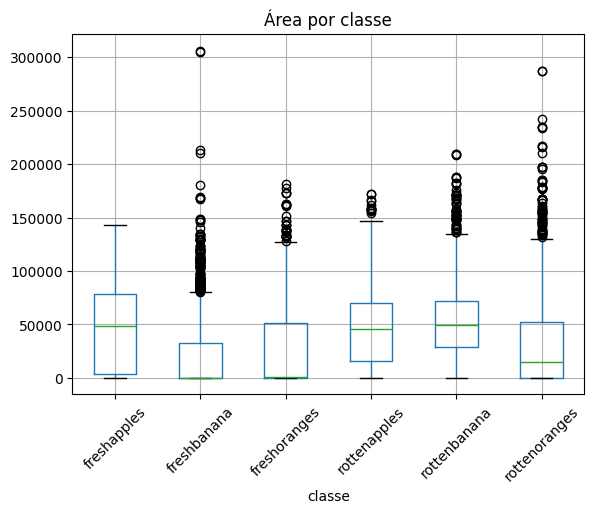

In [19]:
# Boxplot da feature "area" por classe
# Permite visualizar a distribuição da feature "area" para cada classe do dataset, facilitando a análise
# de separabilidade entre categorias

# Configuração do tamanho da figura
plt.figure(figsize=(10,5))

# Boxplot da área separada por classe
temp.boxplot(
    column="area",
    by="classe",
    rot=45
)

# Título principal do gráfico
plt.title("Área por classe")

# Remove título automático gerado pelo pandas
plt.suptitle("")

# Exibe o gráfico
plt.show()

<Figure size 1000x500 with 0 Axes>

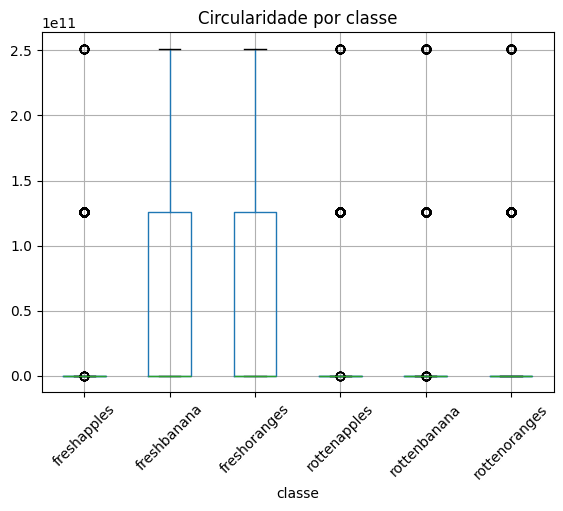

In [20]:
# Boxplot da feature "circularity" por classe
# Permite analisar a distribuição da circularidade entre as classes

plt.figure(figsize=(10,5))

temp.boxplot(
    column="circularity",
    by="classe",
    rot=45
)

plt.title("Circularidade por classe")

plt.suptitle("")

plt.show()

<Figure size 1000x500 with 0 Axes>

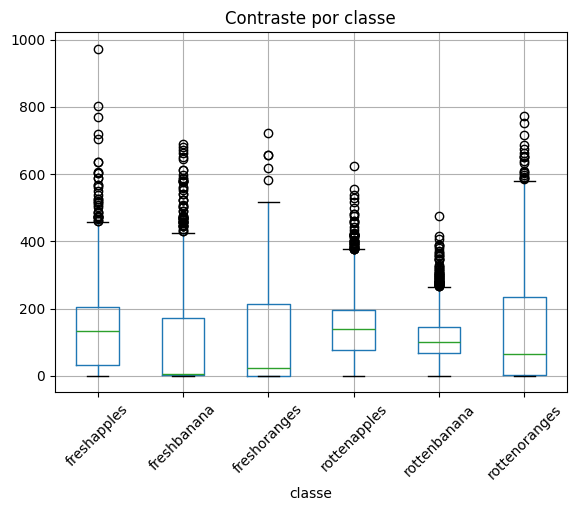

In [21]:
# Boxplot da feature "contrast" por classe
# Permite visualizar a distribuição do contraste entre as classes

plt.figure(figsize=(10,5))

temp.boxplot(
    column="contrast",
    by="classe",
    rot=45
)

plt.title("Contraste por classe")

plt.suptitle("")

plt.show()